# Copyright Rayyan Hodges, TAFE NSW, Gelos Enterprises, Indigo Community Services and Health Hub, Amazon © 2026

# Contact: rayyan.hodges@studytafensw.edu.au, rayyan.hodges@gelosmail.com.au, indigoCSHH@hmail.com

# Program Name: HospitalWaitTimeCalc.ipynb

# Purpose: To automate the caculation of wait time within a hospital for patients and provide a model file for Indigo CSHH to use within their wait time calculator web app.

In [1]:
import pandas as pd
url = "Data/WaitingTimes.csv"
df_indigo = pd.read_csv(url,sep = ',')


## pandas DataFrame

In [2]:
df_indigo.shape

(100050, 15)

In [3]:
df_indigo.head()

,DayOfWeek,TimeOfDay,PatientAge,PatientGender,NumDoctorsOnDuty,NumReceptionistsOnDuty,Temperature,Rainfall,PctPriorVacantSlots,PriorEmergency,AvgDoctorExperience,PctSwitch,AvgAgePrior,AvgGenderPrior,WaitTime
0,2,27,17,0,3,2,39.3,2.5,0.218,0,23.9,0.22,42.2,0.38,0.0
1,4,13,67,0,1,2,39.0,2.3,0.083,0,18.0,0.22,31.1,0.54,9.6
2,2,19,66,0,4,1,-0.8,4.8,0.222,1,13.0,0.23,42.4,0.30,35.7
3,2,26,8,1,3,2,35.8,0.0,0.200,0,17.3,0.32,42.4,0.59,0.0
4,3,23,52,1,3,2,27.3,0.0,0.167,0,17.1,0.36,50.4,0.30,0.0


## Index and column names

In [4]:
df_indigo.columns

Index(['DayOfWeek', 'TimeOfDay', 'PatientAge', 'PatientGender',
       'NumDoctorsOnDuty', 'NumReceptionistsOnDuty', 'Temperature', 'Rainfall',
       'PctPriorVacantSlots', 'PriorEmergency', 'AvgDoctorExperience',
       'PctSwitch', 'AvgAgePrior', 'AvgGenderPrior', 'WaitTime'],
      dtype='object')

In [5]:
df_indigo.index

RangeIndex(start=0, stop=100050, step=1)

## DataFrame schema

In [6]:
df_indigo.dtypes

DayOfWeek                   int64
TimeOfDay                   int64
PatientAge                  int64
PatientGender               int64
NumDoctorsOnDuty            int64
NumReceptionistsOnDuty      int64
Temperature               float64
Rainfall                  float64
PctPriorVacantSlots       float64
PriorEmergency              int64
AvgDoctorExperience       float64
PctSwitch                 float64
AvgAgePrior               float64
AvgGenderPrior            float64
WaitTime                  float64
dtype: object

In [7]:
df_indigo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100050 entries, 0 to 100049
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   DayOfWeek               100050 non-null  int64  
 1   TimeOfDay               100050 non-null  int64  
 2   PatientAge              100050 non-null  int64  
 3   PatientGender           100050 non-null  int64  
 4   NumDoctorsOnDuty        100050 non-null  int64  
 5   NumReceptionistsOnDuty  100050 non-null  int64  
 6   Temperature             100050 non-null  float64
 7   Rainfall                100050 non-null  float64
 8   PctPriorVacantSlots     100050 non-null  float64
 9   PriorEmergency          100050 non-null  int64  
 10  AvgDoctorExperience     100050 non-null  float64
 11  PctSwitch               100050 non-null  float64
 12  AvgAgePrior             100050 non-null  float64
 13  AvgGenderPrior          100050 non-null  float64
 14  WaitTime            

## Check whether the dataset includes imbalances and biases - Rayyan Hodges

In [8]:
df_indigo.describe()

,DayOfWeek,TimeOfDay,PatientAge,PatientGender,NumDoctorsOnDuty,NumReceptionistsOnDuty,Temperature,Rainfall,PctPriorVacantSlots,PriorEmergency,AvgDoctorExperience,PctSwitch,AvgAgePrior,AvgGenderPrior,WaitTime
count,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000,100050.000000
mean,2.995792,16.510825,44.473263,0.599320,2.500880,1.499550,19.992344,4.039394,0.194054,0.050665,14.982076,0.250032,35.011282,0.499615,8.145111
std,1.414105,9.236548,26.030136,0.490039,1.117923,0.500002,10.011279,5.896178,0.108003,0.219313,4.965038,0.049979,10.028119,0.149916,8.295259
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-21.000000,0.000000,0.000000,0.000000,2.000000,0.030000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,22.000000,0.000000,2.000000,1.000000,13.200000,0.000000,0.143000,0.000000,11.600000,0.220000,28.300000,0.400000,4.500000
50%,3.000000,17.000000,44.000000,1.000000,3.000000,1.000000,20.000000,0.000000,0.194000,0.000000,15.000000,0.250000,35.000000,0.500000,6.900000
75%,4.000000,25.000000,67.000000,1.000000,4.000000,2.000000,26.700000,6.800000,0.250000,0.000000,18.300000,0.280000,41.800000,0.600000,10.800000
max,5.000000,32.000000,89.000000,1.000000,4.000000,2.000000,60.700000,42.300000,1.000000,1.000000,38.200000,0.460000,83.300000,1.000000,239.700000


## Identify and remove duplicate rows within dataset - Rayyan Hodges

In [9]:
# Identify duplicate rows
df_indigo.duplicated().sum()

np.int64(50)

In [10]:
# Remove duplicate rows 
df_indigo = df_indigo.drop_duplicates()

In [11]:
# Verify removal of duplicate rows
df_indigo.shape

(100000, 15)

## Categorical statistics identify frequency of values and class imbalances - Rayyan Hodges

## Plotting attribute statistics

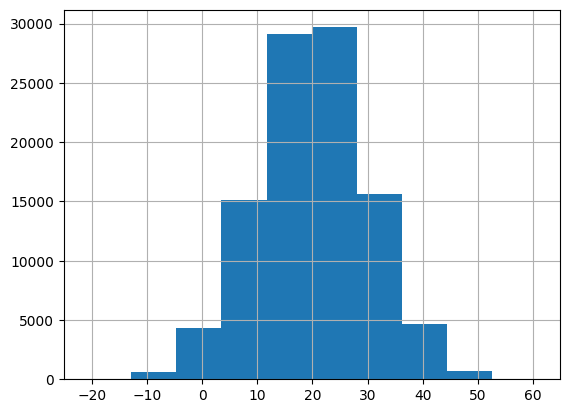

In [12]:
import matplotlib.pyplot as plt
df_indigo['Temperature'].hist(bins=10)
plt.show()

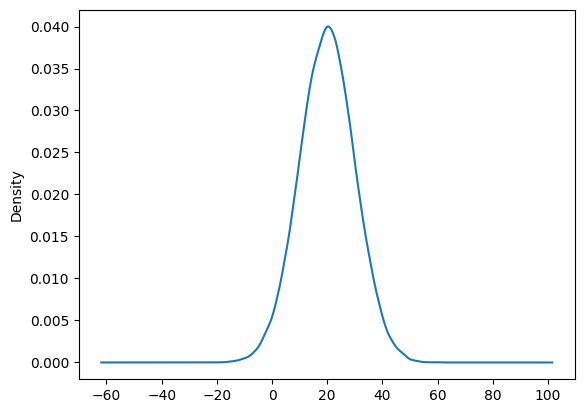

In [13]:
df_indigo['Temperature'].plot.kde()
plt.show()

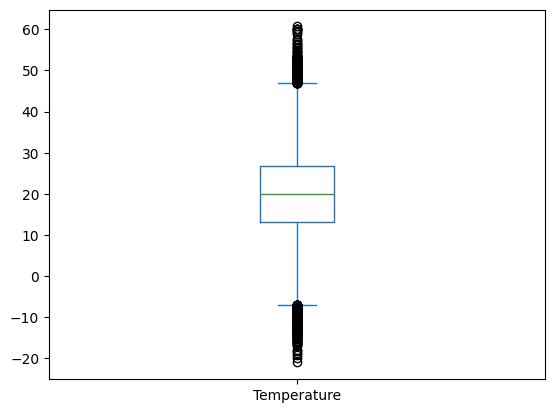

In [14]:
df_indigo['Temperature'].plot.box()
plt.show()

## Plotting multivariate statistics

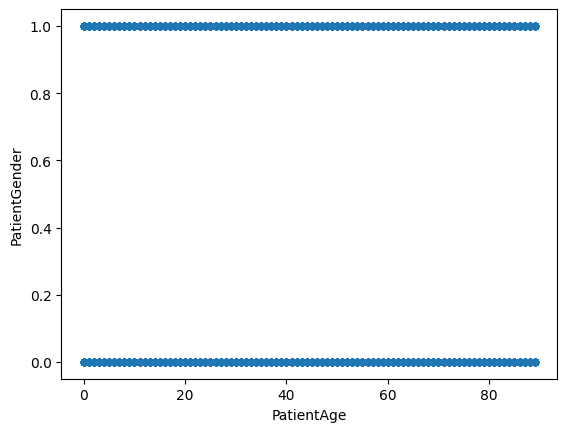

In [15]:
df_indigo.plot.scatter(
    x='PatientAge', 
    y='PatientGender')
plt.show()

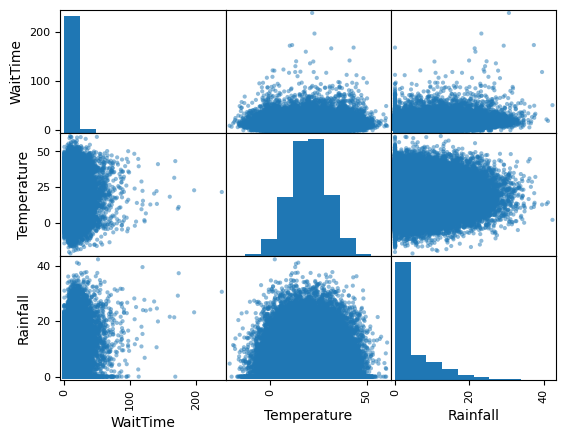

In [16]:
pd.plotting.scatter_matrix(
    df_indigo[['WaitTime',
        'Temperature',
        'Rainfall']])
plt.show()

## Scatter plot with identification

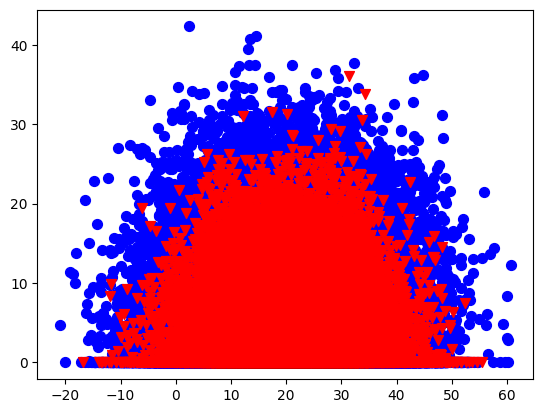

In [17]:
high = df_indigo[['Temperature','Rainfall']][df_indigo['WaitTime']>7]
low = df_indigo[['Temperature','Rainfall']][df_indigo['WaitTime']<=7]

plt.scatter(high['Temperature'],high['Rainfall'],s=50,c='blue',marker='o',label='great')
plt.scatter(x=low['Temperature'],y=low['Rainfall'],s=50,c='red',marker='v',label='poor')

## Correlation matrix

In [18]:
corr_matrix = df_indigo.corr()
corr_matrix["WaitTime"].sort_values(ascending=False)

WaitTime                  1.000000
PriorEmergency            0.395260
Rainfall                  0.331153
TimeOfDay                 0.009291
DayOfWeek                 0.001455
AvgAgePrior               0.000892
PatientGender             0.000879
AvgGenderPrior           -0.001521
Temperature              -0.001547
PatientAge               -0.001581
PctPriorVacantSlots      -0.259315
NumReceptionistsOnDuty   -0.280299
PctSwitch                -0.283324
AvgDoctorExperience      -0.284146
NumDoctorsOnDuty         -0.287974
Name: WaitTime, dtype: float64

## Correlation matrix heatmap

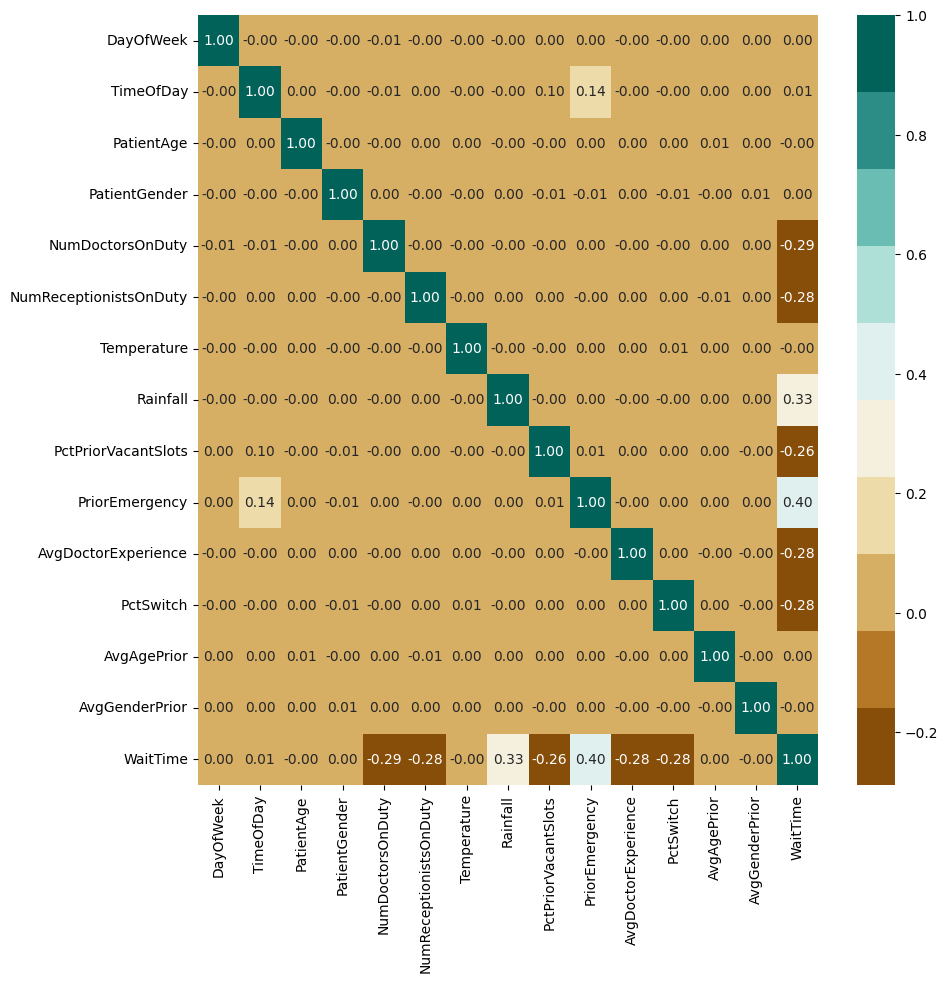

In [19]:
import seaborn as sns
column_names = df_indigo.columns

correlations = df_indigo.corr()
fig, ax = plt.subplots(figsize=(10, 10))

colormap = sns.color_palette("BrBG", 10)

sns.heatmap(correlations, 
    cmap=colormap, 
    annot=True, 
    fmt=".2f")

ax.set_yticklabels(column_names);

plt.show()


## Imputing missing data

In [20]:
from sklearn.impute import SimpleImputer

import numpy as np
# arr = np.array([[5,3,2,2],[3,None,1,9],[5,2,7,None]])
# print(arr)

## Training a model - Rayyan Hodges

In [21]:
# df_indigo['quality']=df_indigo['quality'].map({3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5})

In [22]:
cols = df_indigo.columns.tolist()
cols = cols[-1:] + cols[:-1]
df_indigo = df_indigo[cols]
df_indigo.head()

,WaitTime,DayOfWeek,TimeOfDay,PatientAge,PatientGender,NumDoctorsOnDuty,NumReceptionistsOnDuty,Temperature,Rainfall,PctPriorVacantSlots,PriorEmergency,AvgDoctorExperience,PctSwitch,AvgAgePrior,AvgGenderPrior
0,0.0,2,27,17,0,3,2,39.3,2.5,0.218,0,23.9,0.22,42.2,0.38
1,9.6,4,13,67,0,1,2,39.0,2.3,0.083,0,18.0,0.22,31.1,0.54
2,35.7,2,19,66,0,4,1,-0.8,4.8,0.222,1,13.0,0.23,42.4,0.30
3,0.0,2,26,8,1,3,2,35.8,0.0,0.200,0,17.3,0.32,42.4,0.59
4,0.0,3,23,52,1,3,2,27.3,0.0,0.167,0,17.1,0.36,50.4,0.30


In [23]:
pd.set_option('display.precision', 6)

In [24]:
df_indigo.shape

(100000, 15)

In [25]:
df_indigo.head(20)

,WaitTime,DayOfWeek,TimeOfDay,PatientAge,PatientGender,NumDoctorsOnDuty,NumReceptionistsOnDuty,Temperature,Rainfall,PctPriorVacantSlots,PriorEmergency,AvgDoctorExperience,PctSwitch,AvgAgePrior,AvgGenderPrior
0,0.0,2,27,17,0,3,2,39.3,2.5,0.218,0,23.9,0.22,42.2,0.38
1,9.6,4,13,67,0,1,2,39.0,2.3,0.083,0,18.0,0.22,31.1,0.54
2,35.7,2,19,66,0,4,1,-0.8,4.8,0.222,1,13.0,0.23,42.4,0.30
3,0.0,2,26,8,1,3,2,35.8,0.0,0.200,0,17.3,0.32,42.4,0.59
4,0.0,3,23,52,1,3,2,27.3,0.0,0.167,0,17.1,0.36,50.4,0.30
5,5.1,1,4,3,1,3,1,24.1,0.2,0.333,0,18.7,0.12,43.4,0.50
6,6.1,1,18,49,0,2,1,33.7,0.0,0.206,0,17.5,0.27,33.2,0.44
7,24.0,2,24,59,0,2,1,16.7,0.0,0.239,1,14.6,0.21,48.3,0.51
8,6.1,2,28,57,0,2,2,24.7,12.3,0.204,0,22.1,0.28,54.6,0.55
9,0.0,2,20,43,1,4,2,19.5,0.2,0.171,0,12.4,0.27,35.9,0.45


## Splitting the data into 80/20 - Rayyan Hodges

In [26]:
from sklearn.model_selection import train_test_split

## Confirm that the entire dataset is either labelled or unlabelled (as required for the project). - Rayyan Hodges

In [27]:
X = df_indigo.drop(columns="WaitTime")
y = df_indigo["WaitTime"]

In [28]:
X.shape

(100000, 14)

In [29]:
y.shape

(100000,)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                            test_size=0.2, 
                                            random_state=42 
                                            )

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 14)
(20000, 14)
(80000,)
(20000,)


## Creating the estimator

In [32]:
! pip install xgboost

In [33]:
import xgboost as xgb

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


## Training the model - Rayyan Hodges

In [34]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

## Performing a batch transform on the test data - Rayyan Hodges

In [35]:
raw_predictions = model.predict(X_test)
y_pred = [max(0, time) for time in raw_predictions] # Force negative values to be 0.

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 1.938349454122912
RMSE: 2.8765470259806714


# Compare the actual outputs with the expected outputs. - Rayyan Hodges

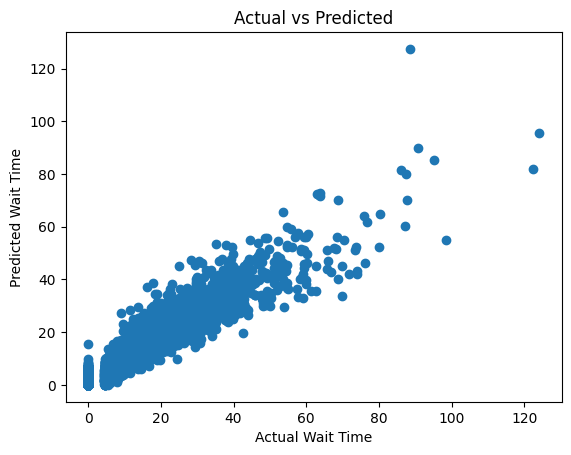

In [37]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Wait Time")
plt.ylabel("Predicted Wait Time")
plt.title("Actual vs Predicted")
plt.show()


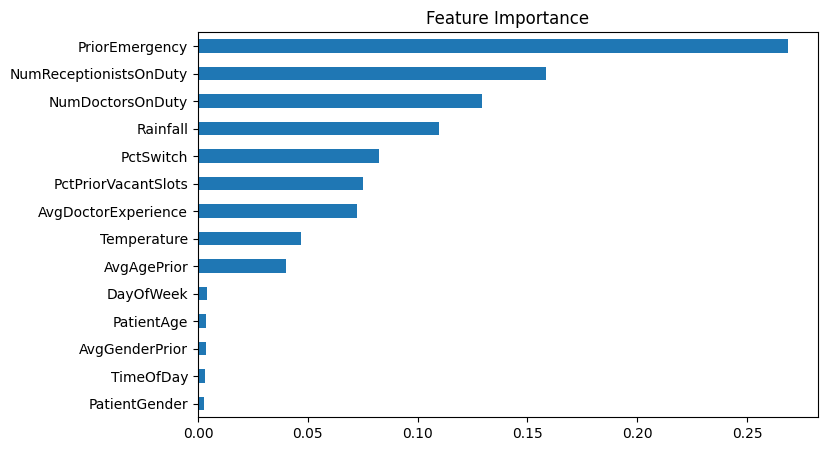

In [38]:
importance = model.feature_importances_
features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance")
plt.show()


# Adjust the relevant hyperparameters of the algorithm to improve the outputs. - Rayyan Hodges

In [39]:
import xgboost as xgb

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=400, # Double the model size
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

## Retrain the adjusted ML model with the training data. - Rayyan Hodges

In [40]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

## Run the test data through the adjusted ML model. - Rayyan Hodges

In [41]:
raw_predictions = model.predict(X_test)
y_pred = [max(0, time) for time in raw_predictions] # Force negative values to be 0.

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 1.939217682468989
RMSE: 2.841806245696892


## Check that the results are accurate, according to the expected outputs. - Rayyan Hodges

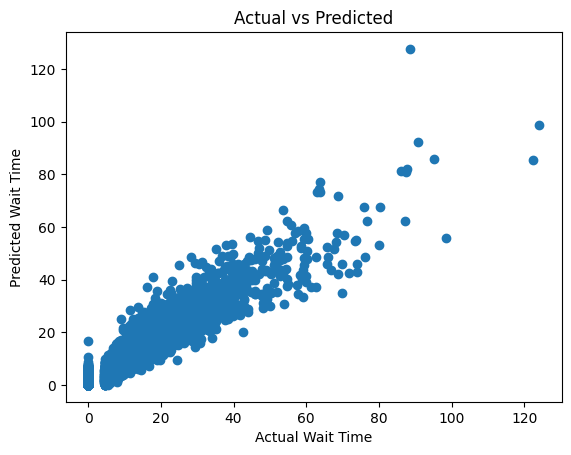

In [43]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Wait Time")
plt.ylabel("Predicted Wait Time")
plt.title("Actual vs Predicted")
plt.show()


## Save the trained model for reuse - Rayyan Hodges

In [44]:
import joblib

In [45]:
joblib.dump(model, "model.pkl")

['model.pkl']